# 🧹 Duplicate File Finder - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/duplicate-finder/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/duplicate-finder/demo.ipynb)

> *"Our shared drive has 50GB of duplicates."*

Finds byte-identical files hiding under different names - **efficiently**. Instead of
hashing everything, it cheapens the work in three passes (size → partial hash → full
hash), so only files that *might* collide ever get fully read.

**What we cover**
1. Build a messy sample tree
2. The 3-pass strategy (and why it's fast)
3. Find the duplicate groups
4. How much space is reclaimable
5. Visualize the waste


## Step 1 - A messy folder with hidden duplicates

Same content, different names, scattered across subfolders - exactly how real shared
drives rot.


In [1]:
from __future__ import annotations
import hashlib, os, tempfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List

root = Path(tempfile.mkdtemp(prefix="dupdemo_"))
(root/"a").mkdir(); (root/"b").mkdir()
report = b"quarterly report data " * 2000          # ~44 KB
(root/"report.csv").write_bytes(report)
(root/"a"/"report_copy.csv").write_bytes(report)
(root/"b"/"report_FINAL.csv").write_bytes(report)
logo = b"PNGDATA" * 3000                             # ~21 KB
(root/"logo.png").write_bytes(logo)
(root/"a"/"logo (1).png").write_bytes(logo)
(root/"unique.txt").write_bytes(b"one of a kind")
print("sample tree:", root)
for p in sorted(root.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(root)}  ({p.stat().st_size} B)")

sample tree: /var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/dupdemo_tq159g3_
  a/logo (1).png  (21000 B)
  a/report_copy.csv  (44000 B)
  b/report_FINAL.csv  (44000 B)
  logo.png  (21000 B)
  report.csv  (44000 B)
  unique.txt  (13 B)


## Step 2 - The 3-pass strategy

Hashing every file is wasteful. We narrow candidates cheaply first:
1. **Group by size** - a unique size can't have a duplicate. (just a `stat`)
2. **Partial hash** (first 4 KB) within each size group - cheap read.
3. **Full hash** only within partial-hash collisions - the expensive read, rarely needed.


In [2]:
CHUNK = 4096
def _files(root):
    for dp,_,fs in os.walk(root):
        for n in fs:
            p = Path(dp)/n
            if p.is_file() and not p.is_symlink():
                yield p

def _partial(path):
    h = hashlib.sha256()
    with path.open("rb") as f: h.update(f.read(CHUNK))
    return h.hexdigest()

def _full(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for b in iter(lambda: f.read(1<<20), b""): h.update(b)
    return h.hexdigest()

def _group_by(items, key):
    g: Dict[object,List[Path]] = {}
    for it in items: g.setdefault(key(it), []).append(it)
    return {k:v for k,v in g.items() if len(v)>1}

all_files = list(_files(root))
by_size = _group_by(all_files, lambda p: p.stat().st_size)
print(f"{len(all_files)} files -> {sum(len(v) for v in by_size.values())} share a size with another")

6 files -> 5 share a size with another


## Step 3 - Find the duplicate groups

Chain the three passes. Only same-size, same-partial-hash files get fully hashed.


In [3]:
@dataclass
class DupGroup:
    file_hash: str; size: int; paths: List[str]
    @property
    def count(self): return len(self.paths)
    @property
    def wasted(self): return self.size*(self.count-1)

def find_duplicates(root, min_size=1):
    root = Path(root)
    by_size = _group_by((p for p in _files(root) if p.stat().st_size>=min_size),
                        lambda p: p.stat().st_size)
    cand = [p for v in by_size.values() for p in v]
    by_partial = _group_by(cand, _partial)
    cand = [p for v in by_partial.values() for p in v]
    by_full = _group_by(cand, _full)
    groups = [DupGroup(str(h), v[0].stat().st_size, sorted(map(str,v))) for h,v in by_full.items()]
    return sorted(groups, key=lambda g: g.wasted, reverse=True)

groups = find_duplicates(root)
for g in groups:
    print(f"{g.count}x {g.size} B  (waste {g.wasted} B)")
    for p in g.paths: print("   ", Path(p).name)

3x 44000 B  (waste 88000 B)
    report_copy.csv
    report_FINAL.csv
    report.csv
2x 21000 B  (waste 21000 B)
    logo (1).png
    logo.png


## Step 4 - How much space is reclaimable

Keep one copy per group, the rest is recoverable.


In [4]:
def human(n):
    s=float(n)
    for u in ("B","KB","MB","GB","TB"):
        if s<1024 or u=="TB": return f"{s:.1f} {u}"
        s/=1024

total_files = len(all_files)
redundant = sum(g.count-1 for g in groups)
wasted = sum(g.wasted for g in groups)
print(f"files scanned : {total_files}")
print(f"duplicate sets: {len(groups)}")
print(f"redundant     : {redundant} files")
print(f"reclaimable   : {human(wasted)}")

files scanned : 6
duplicate sets: 2
redundant     : 3 files
reclaimable   : 106.4 KB


## Step 5 - Visualize the waste

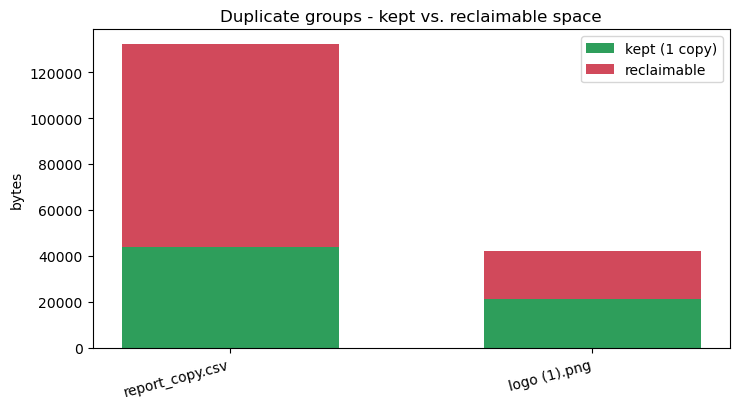

In [5]:
import matplotlib.pyplot as plt

labels = [Path(g.paths[0]).name for g in groups]
kept = [g.size for g in groups]
waste = [g.wasted for g in groups]

import numpy as np
x = np.arange(len(labels)); w = 0.6
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(x, kept, w, label="kept (1 copy)", color="#2e9e5b")
ax.bar(x, waste, w, bottom=kept, label="reclaimable", color="#d1495b")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("bytes"); ax.set_title("Duplicate groups - kept vs. reclaimable space")
ax.legend(); plt.tight_layout()
plt.savefig("waste.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- **Three cheapening passes** (size → partial hash → full hash) mean we rarely read a
  whole file - fast even on large trees.
- Output is **duplicate groups + reclaimable bytes**, biggest waste first.
- The CLI is **dry-run by default**; `--delete` keeps one file per group and removes the rest.

This is the engine behind `main.py`.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run it:**
```bash
python main.py /path/to/folder            # report (safe, dry run)
python main.py /path/to/folder --json     # machine-readable
python main.py /path/to/folder --delete   # remove extras, keep one per group
python main.py --demo                     # try it on a sample tree
```
